# New OHE vs PLM comparison

This notebook recycles the visualizations from `classifier_over_embeddings.ipynb` and `classifier_over_subsamples.ipynb`, but loads the current collected scorer CSVs.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import seaborn as sns
import scipy.stats as stats

plt.rcParams['svg.fonttype'] = 'none'

# Fallbacks for the old plotting code. Keep these names because the visualization cells below
# are copied from classifier_over_embeddings.ipynb.
title_fontsize = 8
label_fontsize = 9
tick_fontsize = 9
legend_fontsize = 7

ylabel_dict = {
    "correlation": "Correlation",
    "pearson": "Pearson",
    "spearman": "Spearman",
    "roc": "ROC (AUC)",
    "roc_auc": "ROC (AUC)",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "accuracy": "Accuracy",
    "top_100_pct": "Precision@K",
    "precision_at_k": "Precision@K class 1",
    "precision_0_at_k": "Precision@K class 0",
    "precision_1_at_k": "Precision@K class 1",
    "mse": "MSE",
}

xlabel_dict = {
    "model_name": "Model",
    "train_mutations": "Training mutations",
    "scale": "Scale",
}

def is_precision_like_metric(metric):
    return metric in {
        "precision",
        "top_100_pct",
        "precision_at_k",
        "precision_0_at_k",
        "precision_1_at_k",
    }


def fix_ticks(ax, x=True, y=True, every_other=False, xlim=None, ylim=None, xbreaks=3, ybreaks=3, fontsize=8):
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    if x:
        ticks = ax.get_xticks()
        if every_other:
            ticks = ticks[::2]
        ax.set_xticks(ticks)
        ax.tick_params(axis='x', labelsize=fontsize)
    if y:
        ticks = ax.get_yticks()
        if every_other:
            ticks = ticks[::2]
        ax.set_yticks(ticks)
        ax.tick_params(axis='y', labelsize=fontsize)


In [2]:
# Point this to the collected scorer outputs from collect_scored_results.py.
# Usually one of:
#   /path/to/scoring_cache/regressor/results/collected
#   /path/to/scoring_cache/classifier/results/collected
COLLECTED_DIR = Path("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/scoring_cache/regressor/results/collected")

# Optional, only used to turn random train sizes into fractions for the subsampling plot.
SEQUENCE_DF_PATH = Path("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/nmt/nmt.csv")
DATASET_NAME = "nmt"

# Choose which architecture-validation method to visualize.
# Mutation choices: "all", "less_than_K", "equal_to_K", "full". Aliases: "less", "equal", "eq".
# Random choices: "all", "full", "random_internal". Aliases: "random", "internal".
MUTATION_VALIDATION_METHOD = "all"
RANDOM_VALIDATION_METHOD = "all"

# Set explicitly for classifier outputs, e.g. "precision_0_at_k" or "precision_1_at_k".
# None means infer: classifiers prefer class-specific precision@K if available; regressors prefer correlation.
FEATURE_TO_PLOT = None

OUTPUT_ROOT = Path("./refined_figures/new_ohe_comp_plm")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(Path("./refined_figures/figure_ohe_vs_llm")).mkdir(parents=True, exist_ok=True)


In [3]:
def read_collected_csv(name, collected_dir=COLLECTED_DIR):
    path = Path(collected_dir) / f"{name}.csv"
    if not path.exists():
        print(f"[load] missing {path}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    df["collection"] = name
    return df


def clean_model_name(value):
    text = str(value)
    if text in {"one_hot", "onehot", "ohe"}:
        return "ohe"
    if text.startswith("mean_"):
        return text.removeprefix("mean_")
    if text.startswith("flat_"):
        return text.removeprefix("flat_")
    return text


def add_metric_aliases(df):
    if df.empty:
        return df
    df = df.copy()
    if "roc" not in df.columns and "roc_auc" in df.columns:
        df["roc"] = df["roc_auc"]
    if "top_100_pct" not in df.columns and "precision_at_k" in df.columns:
        df["top_100_pct"] = df["precision_at_k"]
    if "model_name" in df.columns:
        df["model_name_raw"] = df["model_name"]
        df["model_name"] = df["model_name"].map(clean_model_name)
    if "classifier" in df.columns:
        df["classifier_raw"] = df["classifier"]
    return df


def load_mutation_scorer_data(collected_dir=COLLECTED_DIR):
    by_mutation_val_less = add_metric_aliases(read_collected_csv("by_mutation_val_less", collected_dir))
    by_mutation_val_eq = add_metric_aliases(read_collected_csv("by_mutation_val_eq", collected_dir))
    by_mutation_val_full = add_metric_aliases(read_collected_csv("by_mutation_val_full", collected_dir))

    by_mutation_all = pd.concat(
        [by_mutation_val_less, by_mutation_val_eq, by_mutation_val_full],
        ignore_index=True,
        sort=False,
    )
    return {
        "by_mutation_val_less": by_mutation_val_less,
        "by_mutation_val_eq": by_mutation_val_eq,
        "by_mutation_val_full": by_mutation_val_full,
        "by_mutation_all": by_mutation_all,
    }


def load_random_scorer_data(collected_dir=COLLECTED_DIR):
    random_full = add_metric_aliases(read_collected_csv("random_full", collected_dir))
    random_internal = add_metric_aliases(read_collected_csv("random_internal", collected_dir))
    random_all = pd.concat([random_full, random_internal], ignore_index=True, sort=False)
    return {
        "random_full": random_full,
        "random_internal": random_internal,
        "random_all": random_all,
    }


# Backward-compatible alias for older cells that expected the mutation analysis loader.
def load_current_scorer_data(collected_dir=COLLECTED_DIR):
    return load_mutation_scorer_data(collected_dir)



def collapse_duplicate_mutation_points(df):
    """Match the old plotting assumption: one value per model/train/test point.

    The current collector can contain the same point from full, less_than_K, and
    equal_to_K architecture resolution. The old visualization line plot expects
    one y value for each train_mutations x value, so we summarize duplicates by
    median while preserving source metadata as joined strings.
    """
    if df.empty:
        return df.copy()
    required = ["model_name", "test_mutations", "train_mutations"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"cannot collapse mutation points; missing columns: {missing}")

    numeric_cols = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col not in {"test_mutations", "train_mutations"}
    ]
    metadata_cols = [
        col for col in df.columns
        if col not in set(required + numeric_cols)
    ]

    agg = {col: "median" for col in numeric_cols}
    for col in metadata_cols:
        agg[col] = lambda values: ";".join(sorted({str(value) for value in values.dropna()}))

    collapsed = (
        df.groupby(required, as_index=False)
        .agg(agg)
        .sort_values(required)
        .reset_index(drop=True)
    )
    print(f"[collapse] by-mutation rows: {len(df)} -> {len(collapsed)}")
    return collapsed


def normalize_mutation_validation_method(method):
    aliases = {
        "all": "all",
        "less": "less_than_K",
        "less_than": "less_than_K",
        "less_than_K": "less_than_K",
        "lt": "less_than_K",
        "equal": "equal_to_K",
        "eq": "equal_to_K",
        "equal_to": "equal_to_K",
        "equal_to_K": "equal_to_K",
        "full": "full",
    }
    key = str(method).strip()
    if key not in aliases:
        raise ValueError(f"unknown mutation validation method {method!r}; choose one of {sorted(aliases)}")
    return aliases[key]


def normalize_random_validation_method(method):
    aliases = {
        "all": "all",
        "full": "full",
        "random": "random_internal",
        "internal": "random_internal",
        "random_internal": "random_internal",
    }
    key = str(method).strip()
    if key not in aliases:
        raise ValueError(f"unknown random validation method {method!r}; choose one of {sorted(aliases)}")
    return aliases[key]


def select_mutation_validation_data(current, method=MUTATION_VALIDATION_METHOD):
    method = normalize_mutation_validation_method(method)
    key_by_method = {
        "all": "by_mutation_all",
        "less_than_K": "by_mutation_val_less",
        "equal_to_K": "by_mutation_val_eq",
        "full": "by_mutation_val_full",
    }
    key = key_by_method[method]
    df = current[key].copy()
    print(f"[select] mutation validation method={method} source={key} rows={len(df)}")
    return df


def select_random_validation_data(current, method=RANDOM_VALIDATION_METHOD):
    method = normalize_random_validation_method(method)
    key_by_method = {
        "all": "random_all",
        "full": "random_full",
        "random_internal": "random_internal",
    }
    key = key_by_method[method]
    df = current[key].copy()
    print(f"[select] random validation method={method} source={key} rows={len(df)}")
    return df

def split_ohe_plm(df):
    if df.empty:
        return df.copy(), df.copy()
    ohe_df = df[df["model_name"] == "ohe"].copy()
    plm_df = df[df["model_name"] != "ohe"].copy()
    return plm_df, ohe_df


def has_metric(df, metric):
    return metric in df.columns and df[metric].notna().any()


def looks_like_classifier_results(df):
    classifier_metrics = [
        "roc",
        "roc_auc",
        "precision",
        "precision_at_k",
        "precision_0_at_k",
        "precision_1_at_k",
        "recall",
        "f1",
        "accuracy",
    ]
    return any(has_metric(df, metric) for metric in classifier_metrics)


def choose_metric(df, preferred=None):
    if preferred is not None:
        if not has_metric(df, preferred):
            available = [col for col in df.columns if df[col].notna().any()]
            raise ValueError(f"requested FEATURE_TO_PLOT={preferred!r} is missing/empty; available non-empty columns include: {available}")
        return preferred

    if looks_like_classifier_results(df):
        candidates = [
            "precision_1_at_k",
            "precision_0_at_k",
            "precision_at_k",
            "top_100_pct",
            "precision",
            "roc",
            "roc_auc",
            "f1",
            "accuracy",
            "recall",
        ]
    else:
        candidates = ["correlation", "spearman", "pearson", "mse"]

    for candidate in candidates:
        if has_metric(df, candidate):
            return candidate
    raise ValueError("could not infer a metric column from the collected scorer results")


def best_plm_vs_ohe(df, metric):
    plm_df, ohe_df = split_ohe_plm(df)
    if plm_df.empty or ohe_df.empty:
        print("[compare] missing PLM or OHE rows")
        return pd.DataFrame(), None
    medians = plm_df.groupby("model_name")[metric].median().dropna()
    if medians.empty:
        return pd.DataFrame(), None
    best_model = medians.idxmin() if metric == "mse" else medians.idxmax()
    best_embedding_df = plm_df[plm_df["model_name"] == best_model].copy()
    best_embedding_df["model_name"] = "llm"
    ohe_plot_df = ohe_df.copy()
    ohe_plot_df["model_name"] = "ohe"
    return pd.concat([best_embedding_df, ohe_plot_df], ignore_index=True, sort=False), best_model


def build_ratio_df(df, metric, dataset_name=DATASET_NAME):
    compare_df, best_model = best_plm_vs_ohe(df, metric)
    rows = []
    if compare_df.empty:
        return pd.DataFrame(), best_model
    for train_mutation in sorted(compare_df["train_mutations"].dropna().unique()):
        for test_mutation in sorted(compare_df["test_mutations"].dropna().unique()):
            sub_df = compare_df[
                (compare_df["train_mutations"] == train_mutation)
                & (compare_df["test_mutations"] == test_mutation)
            ]
            if sub_df.empty:
                continue
            ohe_vals = sub_df[sub_df["model_name"] == "ohe"][metric].dropna()
            llm_vals = sub_df[sub_df["model_name"] == "llm"][metric].dropna()
            if ohe_vals.empty or llm_vals.empty:
                continue
            ohe_value = float(ohe_vals.median())
            llm_value = float(llm_vals.median())
            if llm_value == 0:
                continue
            rows.append({
                "train_mutations": train_mutation,
                "test_mutations": test_mutation,
                "ratio": ohe_value / llm_value,
                "ohe_value": ohe_value,
                "llm_value": llm_value,
                "feature": metric,
                "dataset": dataset_name,
                "best_plm_model": best_model,
            })
    return pd.DataFrame(rows), best_model


def collapse_duplicate_subsample_points(df):
    """Match the old subsample plot assumption: one score distribution per model/fraction.

    Current random outputs can contain multiple architecture-resolution sources or
    multiple PLM names. We keep the old visualization labels, ohe vs esm, and
    collapse exact duplicate split/model/fraction rows by median.
    """
    if df.empty:
        return df.copy()
    required = ["model", "fraction"]
    optional = [col for col in ["split_name", "train_mutations"] if col in df.columns]
    group_cols = required + optional
    numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in set(group_cols)]
    metadata_cols = [col for col in df.columns if col not in set(group_cols + numeric_cols)]

    agg = {col: "median" for col in numeric_cols}
    for col in metadata_cols:
        agg[col] = lambda values: ";".join(sorted({str(value) for value in values.dropna()}))

    collapsed = (
        df.groupby(group_cols, as_index=False)
        .agg(agg)
        .sort_values(group_cols)
        .reset_index(drop=True)
    )
    print(f"[collapse] subsample rows: {len(df)} -> {len(collapsed)}")
    return collapsed


def prepare_subsample_data(random_df, metric=None, sequence_df_path=SEQUENCE_DF_PATH):
    if random_df.empty:
        return pd.DataFrame()
    metric = metric or choose_metric(random_df)
    out = random_df.copy()
    out["model"] = np.where(out["model_name"] == "ohe", "ohe", "esm")
    out["roc"] = out[metric]
    if sequence_df_path is not None and Path(sequence_df_path).exists():
        n_rows = len(pd.read_csv(sequence_df_path))
        out["fraction"] = out["train_mutations"].astype(float) / float(n_rows)
    else:
        out["fraction"] = out["train_mutations"].astype(float)
    return collapse_duplicate_subsample_points(out)


current = load_mutation_scorer_data()
for key, value in current.items():
    print(key, value.shape)

df_all_raw = select_mutation_validation_data(current, MUTATION_VALIDATION_METHOD)
df_all = collapse_duplicate_mutation_points(df_all_raw)
plm_df_all, ohe_df_all = split_ohe_plm(df_all)
feature_to_plot = choose_metric(df_all, FEATURE_TO_PLOT)
print("feature_to_plot", feature_to_plot)
print("models", sorted(df_all["model_name"].dropna().unique()) if not df_all.empty else [])


by_mutation_val_less (60, 29)
by_mutation_val_eq (60, 29)
by_mutation_val_full (60, 29)
by_mutation_all (180, 29)
[select] mutation validation method=all source=by_mutation_all rows=180
[collapse] by-mutation rows: 180 -> 60
feature_to_plot correlation
models ['esm_35m', 'esm_8m', 'ohe']


In [4]:
# Explicit validation-method dataframes.
# These make it easy to inspect/plot full without relying on the config variable.
df_less_raw = select_mutation_validation_data(current, "less_than_K")
df_equal_raw = select_mutation_validation_data(current, "equal_to_K")
df_full_raw = select_mutation_validation_data(current, "full")

df_less = collapse_duplicate_mutation_points(df_less_raw)
df_equal = collapse_duplicate_mutation_points(df_equal_raw)
df_full = collapse_duplicate_mutation_points(df_full_raw)

print("df_less", df_less.shape)
print("df_equal", df_equal.shape)
print("df_full", df_full.shape)


[select] mutation validation method=less_than_K source=by_mutation_val_less rows=60
[select] mutation validation method=equal_to_K source=by_mutation_val_eq rows=60
[select] mutation validation method=full source=by_mutation_val_full rows=60
[collapse] by-mutation rows: 60 -> 60
[collapse] by-mutation rows: 60 -> 60
[collapse] by-mutation rows: 60 -> 60
df_less (60, 29)
df_equal (60, 29)
df_full (60, 29)


In [5]:
def plot_mutation_model_performance(
    color_map, 
    df_all, 
    pred_begin, 
    min_muts, 
    n_muts_to_check, 
    feature_to_plot, 
    probabilities_by_mutations=None,
    output_dir=None,
    min_max_y=False
):
    filtered_df_all = df_all[df_all["model_name"].isin(color_map.keys())]
    col_size = 1.35
    row_size = col_size * n_muts_to_check
    title_fontsize = 8
    label_fontsize = 9
    tick_fontsize = 9
    legend_fontsize = 7

    plot_boxplots = False

    def finite_box_values(groups):
        finite_groups = []
        for group in groups:
            values = np.asarray(group, dtype=float).ravel()
            values = values[np.isfinite(values)]
            if values.size > 0:
                finite_groups.append(values)
        return finite_groups

    def empty_panel_ylim():
        return (0, 1) if is_precision_like_metric(feature_to_plot) else (-0.05, 0.05)

    fig, axs = plt.subplots(2, n_muts_to_check, figsize=(row_size, 0.3 + col_size*2), constrained_layout=True)

    if min_max_y:
        # calculate global y min/max for line plots if needed
        all_measurements = []
        for i in range(min_muts, min_muts+n_muts_to_check):
            sub_df = filtered_df_all[filtered_df_all["test_mutations"] == i]
            train_sub_df = sub_df[(sub_df["train_mutations"] < i) & (sub_df["train_mutations"] >= pred_begin)]
            for model in color_map.keys():
                vals = train_sub_df[(train_sub_df["model_name"] == model)][feature_to_plot].values
                vals = vals[~np.isnan(vals)]
                if len(vals) > 0:
                    all_measurements.extend(vals)
        if len(all_measurements) > 0:
            global_ymin = np.nanmin(all_measurements)
            global_ymax = np.nanmax(all_measurements)
        else:
            global_ymin = 0
            global_ymax = 1

    for i in range(min_muts, min_muts+n_muts_to_check):
        col = i - min_muts
        axs[0, col].grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
        axs[1, col].grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
        axs[0, col].spines['right'].set_visible(False)
        axs[1, col].spines['right'].set_visible(False)
        axs[0, col].spines['top'].set_visible(False)
        axs[1, col].spines['top'].set_visible(False)

        sub_df = filtered_df_all[filtered_df_all["test_mutations"] == i]
        train_sub_df = sub_df[(sub_df["train_mutations"] < i) & (sub_df["train_mutations"] >= pred_begin)]
        train_mutation_values = sorted(np.unique(train_sub_df["train_mutations"]))
        n_train_muts = len(train_mutation_values)
        x = np.arange(n_train_muts)
        width = 1/n_muts_to_check
        multiplier = 0

        # --- SWAP BEGINS: original axs[0] code moved to axs[1], and boxplot code to axs[0] ---

        # First plot what *was* on row 1 (boxplot) on axs[0]
        boxplot_data = []
        model_names = []
        
        for model in color_map.keys():
            box_vals = filtered_df_all[(filtered_df_all["test_mutations"] == i) & (filtered_df_all["model_name"] == model)][feature_to_plot].dropna().values
            if len(box_vals) > 0:
                if box_vals.ndim == 2:
                    box_vals = box_vals.squeeze()
                boxplot_data.append(box_vals)
                model_names.append(model)
                
        finite_groups = finite_box_values(boxplot_data)
        if finite_groups:
            bp = axs[0, col].boxplot(
                finite_groups,
                patch_artist=True,
                boxprops=dict(linewidth=1, color='black'),
                medianprops=dict(color='black', linewidth=1),
                whiskerprops=dict(linewidth=1, color='black'),
                capprops=dict(linewidth=1, color='black'),
                flierprops=dict(markerfacecolor='black', marker='o', markersize=3.5, markeredgecolor='black', linestyle='none')
            )        

            for patch, model in zip(bp['boxes'], model_names):
                patch.set_facecolor(color_map[model])
        else:
            axs[0, col].text(0.5, 0.5, 'no data', ha='center', va='center', transform=axs[0, col].transAxes, fontsize=tick_fontsize)
        axs[0, col].set_xlabel('Model', fontsize=label_fontsize, labelpad=3)
        axs[0, col].set_xticklabels([])
        axs[0, col].tick_params(axis='y', labelsize=tick_fontsize)

        if is_precision_like_metric(feature_to_plot):
            if finite_groups:
                all_box_vals = np.concatenate(finite_groups)
                y_min = np.nanmin(all_box_vals)
                y_max = np.nanmax(all_box_vals)
                y_pad = (y_max - y_min) * 0.1 if y_max > y_min else 0.05
                y_lower = max(0, y_min - y_pad)
                y_upper = min(1, y_max + y_pad)
            else:
                y_lower, y_upper = empty_panel_ylim()
            for s in [0.5, 0.2, 0.1]:
                dec_y_lower = np.ceil(y_lower / s) * s
                dec_y_upper = np.floor(y_upper / s) * s
                n_ticks = int((dec_y_upper - dec_y_lower) / s) + 1
                if n_ticks >= 3 and n_ticks <= 10:
                    tick_step = s
                    break
            else:
                tick_step = 0.1
                dec_y_lower = np.ceil(y_lower / tick_step) * tick_step
                dec_y_upper = np.floor(y_upper / tick_step) * tick_step

            y_ticks = np.arange(dec_y_lower, dec_y_upper + tick_step / 2, tick_step)
            y_ticks = np.clip(y_ticks, 0, 1)
            y_ticks = np.unique(np.round(y_ticks, 3))
            y_ticklabels = []
            for y in y_ticks:
                if np.isclose(y, 0.0):
                    y_ticklabels.append('0')
                elif np.isclose(y, 1.0):
                    y_ticklabels.append('1')
                elif tick_step >= 0.1:
                    y_ticklabels.append(str(int(y*10)/10))
                else:
                    y_ticklabels.append('{:.2f}'.format(y))
            axs[0, col].set_yticks(y_ticks)
            axs[0, col].set_yticklabels(y_ticklabels)
        else:
            if finite_groups:
                all_box_vals = np.concatenate(finite_groups)
                y_min = np.nanmin(all_box_vals)
                y_max = np.nanmax(all_box_vals)
                y_pad = (y_max - y_min) * 0.1 if y_max > y_min else 0.05
                y_lower = y_min - y_pad
                y_upper = y_max + y_pad
            else:
                y_lower, y_upper = empty_panel_ylim()
            axs[0, col].set_ylim(y_lower, y_upper)

        if col == 0:
            axs[0, col].set_ylabel(ylabel_dict[feature_to_plot], labelpad=6, fontsize=label_fontsize)
        
        fix_ticks(axs[0, col], x=False, y=True, every_other=False, ylim=[y_lower, y_upper], fontsize=tick_fontsize)


        # Next, plot what *was* on row 0 (line/bar) on axs[1]
        if not plot_boxplots:
            for model in color_map.keys():
                model_rows = train_sub_df[(train_sub_df["model_name"] == model)].sort_values("train_mutations")
                measurement = model_rows.groupby("train_mutations")[feature_to_plot].mean().reindex(train_mutation_values)
                measurement = measurement.round(2)
                if n_train_muts == 0 or measurement.dropna().empty:
                    continue
                axs[1, col].plot(
                    x, measurement, marker='o', 
                    color=color_map.get(model, None), 
                    label=model if col == 0 else "", 
                    markersize=3, linewidth=1, alpha=0.7
                )
            if col == 0:
                axs[1, col].set_ylabel(ylabel_dict[feature_to_plot], labelpad=6, fontsize=label_fontsize)
            # There is no 'labelpad' argument for set_title in matplotlib.
            # You can control spacing with pad argument (from matplotlib 3.2 onward) or use '\n' in the text.
            axs[0, col].set_title('Mutations in test: %d\n' % i, fontsize=title_fontsize, pad=3)
            axs[1, col].set_xlabel('Mutations\nin train', fontsize=label_fontsize, labelpad=1)
            axs[1, col].set_xticks(x)
            axs[1, col].set_xticklabels(train_mutation_values, fontsize=tick_fontsize)
            axs[1, col].tick_params(axis='y', labelsize=tick_fontsize)
            axs[1, col].tick_params(axis='x', labelsize=tick_fontsize)
            if feature_to_plot == "roc":
                if pred_begin == 2:
                    axs[1, col].set_ylim(0.6, 0.95)
                else:
                    axs[1, col].set_ylim(0.3, 0.95)
            if min_max_y:
                axs[1, col].set_ylim(global_ymin, global_ymax)
            
            if probabilities_by_mutations is not None:
                print(probabilities_by_mutations)
                precision = probabilities_by_mutations[i-1][1]
                if is_precision_like_metric(feature_to_plot):
                    axs[1, col].axhline(y=precision, color='black', linestyle='--', linewidth=0.8)
            if is_precision_like_metric(feature_to_plot):
                axs[1, col].set_ylim(0, 1.05)
                axs[1, col].set_yticks([0, 0.5, 1])
                axs[1, col].set_yticklabels(['0', '0.5', '1'])
            fix_ticks(axs[1, col], x=False, y=True, every_other=False, ylim=None, ybreaks=3, fontsize=tick_fontsize)
        else:
            for model in color_map.keys():
                model_rows = train_sub_df[(train_sub_df["model_name"] == model)].sort_values("train_mutations")
                measurement = model_rows.groupby("train_mutations")[feature_to_plot].mean().reindex(train_mutation_values)
                measurement = measurement.round(2)
                if n_train_muts == 0 or measurement.dropna().empty:
                    continue
                offset = width * multiplier
                rects = axs[1, col].bar(x + offset, measurement, width, color=color_map.get(model, None), label=model if col == 0 else "")
                multiplier += 1
            if col == 0:
                axs[1, col].set_ylabel(feature_to_plot, labelpad=6, fontsize=label_fontsize)
                if min_muts == 3:
                    axs[1, col].legend(loc='lower left', ncols=1, fontsize=legend_fontsize)        
            axs[1, col].set_xlabel('Mutations\nin train', fontsize=label_fontsize, labelpad=1)
            axs[1, col].set_xticks(x + width)
            axs[1, col].set_xticklabels(train_mutation_values, fontsize=tick_fontsize)
            axs[1, col].tick_params(axis='y', labelsize=tick_fontsize)
            axs[1, col].tick_params(axis='x', labelsize=tick_fontsize)
            axs[1, col].set_ylim(0.3, 1.1)
            if min_max_y:
                axs[1, col].set_ylim(global_ymin, global_ymax)

            
            if probabilities_by_mutations is not None:
                print(probabilities_by_mutations)
                precision = probabilities_by_mutations[i-1][1]
                if is_precision_like_metric(feature_to_plot):
                    axs[1, col].axhline(y=precision, color='black', linestyle='--', linewidth=0.8)
            if is_precision_like_metric(feature_to_plot):
                axs[1, col].set_yticks([0, 0.5, 1])
                axs[1, col].set_yticklabels(['0', '0.5', '1'])
            fix_ticks(axs[1, col], x=False, y=True, every_other=False, ylim=None, ybreaks=3, fontsize=tick_fontsize)

        # --- SWAP ENDS ---


    plt.show()

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        fig.savefig(os.path.join(output_dir, "%s.svg" % feature_to_plot), bbox_inches='tight')


var_to_use_dict = {
    "gfp": ["roc", "precision", "f1", "accuracy", "recall", "top_100_pct"],
    "pard3": ["correlation"],
    "lov": ["correlation"],
    "casp": ["correlation"],
    "his": ["correlation"]
}


In [6]:
# Color maps keep the old visual identity where possible.
color_map = {
    "esm_8m": "#002b87",
    "esm_35m": "#f0b800",
    "esm_150m": "#008230",
    "esm_650m": "#bd0000",
    "esm_3b": "#00cfeb",
    "progen2-small": "#ffa500",
    "progen2-medium": "#a603a0",
    "prot_bert": "#3d546b",
}

# Add deterministic fallback colors for any new PLMs/features present in the collected scorer outputs.
extra_models = [m for m in sorted(df_all["model_name"].dropna().unique()) if m not in color_map and m != "ohe"] if not df_all.empty else []
for model, color in zip(extra_models, sns.color_palette("tab10", n_colors=max(len(extra_models), 1)).as_hex()):
    color_map[model] = color

pred_begin = int(df_all["train_mutations"].min()) if not df_all.empty else 1
min_muts = int(max(3, df_all["test_mutations"].min())) if not df_all.empty else 3
n_muts_to_check = int(min(6, df_all["test_mutations"].max() - min_muts + 1)) if not df_all.empty else 6
print(pred_begin, min_muts, n_muts_to_check)


5 6 6


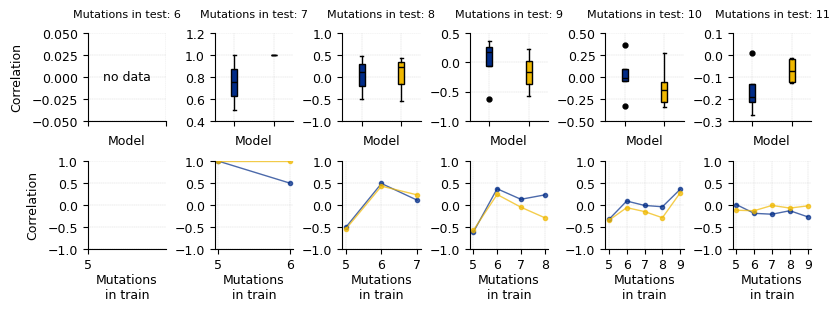

In [ ]:
# Original mutation-panel visualization, now over all PLM rows in the collected scorer data.
# To force full validation here, set: PLOT_DF_OVERRIDE = df_full
PLOT_DF_OVERRIDE = None
plot_source_df = df_all if PLOT_DF_OVERRIDE is None else PLOT_DF_OVERRIDE
plot_plm_df, plot_ohe_df = split_ohe_plm(plot_source_df)

if not plot_plm_df.empty:
    plot_mutation_model_performance(
        {k: v for k, v in color_map.items() if k in set(plot_plm_df["model_name"])},
        plot_plm_df,
        pred_begin,
        min_muts,
        n_muts_to_check,
        feature_to_plot,
        output_dir=str(OUTPUT_ROOT / "plm_comparison"),
        min_max_y=True,
    )
else:
    print("No PLM rows found.")


best_model esm_35m


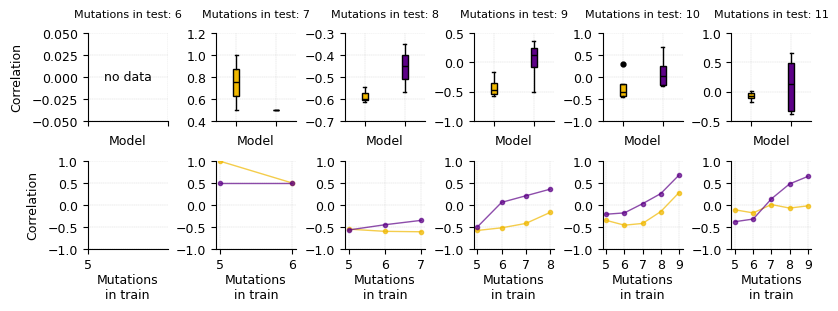

In [ ]:
# Original OHE-vs-best-LLM visualization, adapted to the collected scorer data.
ohe_embedding_df_all, best_model = best_plm_vs_ohe(df_equal, feature_to_plot)
print("best_model", best_model)

if not ohe_embedding_df_all.empty:
    plot_mutation_model_performance(
        {"llm": "#f0b800", "ohe": "#5d0187"},
        ohe_embedding_df_all,
        pred_begin,
        min_muts,
        n_muts_to_check,
        feature_to_plot,
        min_max_y=True,
        output_dir=str(OUTPUT_ROOT / "ohe_vs_llm"),
    )
else:
    print("No OHE-vs-LLM rows found.")


In [25]:
# Prepare the old ratio dataframe expected by the copied improvement visualizations.
ratio_df_all, best_model_for_ratio = build_ratio_df(df_less, feature_to_plot, dataset_name=DATASET_NAME)
if not ratio_df_all.empty:
    ratio_df_all["dataset"] = ratio_df_all["dataset"].astype(str).str.upper()
    ratio_df_all["title_for_plot"] = [ylabel_dict.get(k, k) for k in ratio_df_all["feature"].to_list()]
ratio_df_all.head()


,train_mutations,test_mutations,ratio,ohe_value,llm_value,feature,dataset,best_plm_model,title_for_plot
0,5,7,-2.000000,1.000000,-0.500000,correlation,NMT,esm_8m,Correlation
1,5,8,-0.596591,-0.296371,0.496774,correlation,NMT,esm_8m,Correlation
2,5,9,-0.503892,-0.310353,0.615912,correlation,NMT,esm_8m,Correlation
3,5,10,-0.046107,-0.014584,0.316308,correlation,NMT,esm_8m,Correlation
4,5,11,1.105882,-0.335714,-0.303571,correlation,NMT,esm_8m,Correlation


/tmp/ipykernel_3397747/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3397747/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3397747/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3397747/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3397747/3118887496.py:53: MatplotlibDeprecationWarning: The 'labels' 

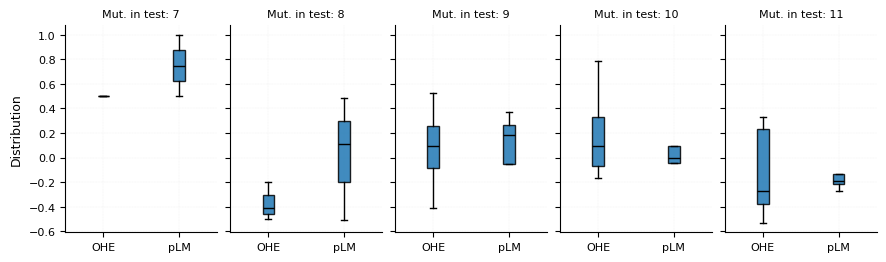

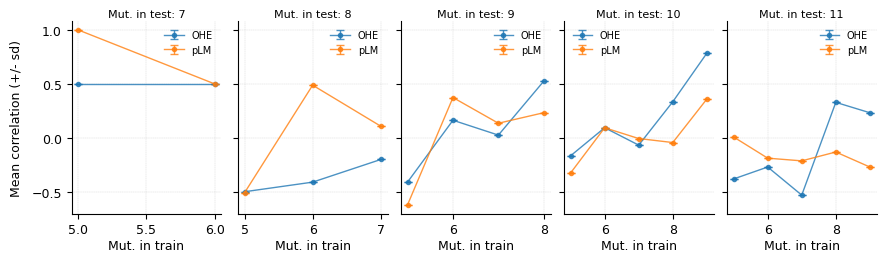

In [23]:

def plot_panel_panel(
    df,
    value_column,
    color_map={'ohe': '#2077B4', 'llm': '#ED594A'},
    plot_type="box",   # "box" or "lines"
    title_fontsize=8,
    label_fontsize=9,
    tick_fontsize=9,
    legend_fontsize=7,
):
    """
    For each unique value in 'test_mutations', creates a subplot in a single row.
    If plot_type == "box", plots a boxplot of value_column for each model, no p-value or t-test.
    If plot_type == "lines", plots the average (+/- sd) of value_column as a function of train_mutations for each model.
    Styling (figsize, fontsize, colors, etc.) is inspired by plot_mutation_model_performance.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    test_mutations_values = sorted(df['test_mutations'].unique())
    test_mutations_values = range(max(3, min(test_mutations_values)), max(test_mutations_values) + 1)
    n_panels = len(test_mutations_values)
    models = df['model'].unique()

    col_size = 1.75  # inspired by plot_mutation_model_performance

    # 1 row: each panel for each test_mutations value
    fig, axes = plt.subplots(
        1, n_panels,
        figsize=(col_size * n_panels, 0.5 + col_size * 1.15),
        constrained_layout=True,
        sharey=True if plot_type=="box" else 'row'
    )

    # If only one panel, axes not an array
    if n_panels == 1:
        axes = np.array([axes])

    for idx, test_mut in enumerate(test_mutations_values):
        ax = axes[idx]
        sub_df = df[df['test_mutations'] == test_mut]

        if plot_type == "box":
            boxplot_data = []
            boxplot_colors = []
            labels = []
            for model in models:
                model_df = sub_df[sub_df['model'] == model]
                boxplot_data.append(model_df[value_column].astype(float).dropna())
                boxplot_colors.append(color_map[model] if model in color_map else None)
                labels.append(str(model))
            # Here, tick_labels is deprecated, use labels instead if using newer matplotlib (>3.9)
            bp = ax.boxplot(
                boxplot_data,
                patch_artist=True,
                labels=labels,
                medianprops=dict(color='black'),
                showfliers=False,
            )
            for patch, color in zip(bp['boxes'], boxplot_colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.85)

            ax.grid(True, which='both', linestyle=':', linewidth=0.2, alpha=0.55)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.tick_params(axis='x', labelsize=tick_fontsize - 1)
            ax.tick_params(axis='y', labelsize=tick_fontsize - 1)
            if idx == 0:
                ax.set_ylabel("Distribution", fontsize=label_fontsize)
            ax.set_title(f"Mut. in test: {test_mut}", fontsize=title_fontsize)
            # No legend for boxplot

        elif plot_type == "lines":
            plotted_any = False
            for model in models:
                model_df = sub_df[sub_df['model'] == model]
                if model_df.empty:
                    continue
                avail_train_mut = sorted(model_df['train_mutations'].unique())
                x_vals, y_means, y_sds = [], [], []
                for train_mut in avail_train_mut:
                    if train_mut > test_mut:
                        continue
                    select = model_df[model_df['train_mutations'] == train_mut]
                    if select.empty:
                        continue
                    x_vals.append(train_mut)
                    y = select[value_column].astype(float)
                    y_means.append(np.nanmean(y))
                    y_sds.append(np.nanstd(y))
                if x_vals:
                    color = color_map[model] if model in color_map else None
                    ax.errorbar(
                        x_vals, y_means, yerr=y_sds, marker='o', label=f"{model}",
                        capsize=3, alpha=0.8, color=color, markersize=3, linewidth=1
                    )
                    plotted_any = True

            ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.set_title(f"Mut. in test: {test_mut}", fontsize=title_fontsize, pad=3)
            ax.set_xlabel("Mut. in train", fontsize=label_fontsize, labelpad=2)
            ax.tick_params(axis='x', labelsize=tick_fontsize)
            ax.tick_params(axis='y', labelsize=tick_fontsize)
            if idx == 0:
                ax.set_ylabel(f"Mean {value_column} (+/- sd)", labelpad=6, fontsize=label_fontsize)
            if plotted_any:
                ax.legend(loc='best', fontsize=legend_fontsize, frameon=False)

    plt.show()


ohe_emb_cols = ['correlation', 'test_mutations', 'train_mutations', 'model_name', 'model', 'dataset']

new_ohe_like_dfs = []

for dataset in np.unique(ratio_df_all["dataset"]):
    df_dataset = ratio_df_all[ratio_df_all["dataset"] == dataset]
    for feature in np.unique(df_dataset["feature"]):
        df = df_dataset[df_dataset["feature"] == feature]
        # Make two melted dfs: one for ohe, one for llm

        ohe_llm = []
        for model_type in ["ohe", "llm"]:
            correlation_val = df["ohe_value"].values if model_type == "ohe" else df["llm_value"].values
            temp = pd.DataFrame({
                "correlation": correlation_val,
                "test_mutations": df["test_mutations"].values,
                "train_mutations": df["train_mutations"].values,
                "model_name": ["OHE" if model_type == "ohe" else "pLM"] * len(df),
                "model": ["OHE" if model_type == "ohe" else "pLM"] * len(df),
                "dataset": [dataset] * len(df)
            })
            new_ohe_like_dfs.append(temp)
            ohe_llm.append(temp)
        ohe_llm_df = pd.concat(ohe_llm, ignore_index=True)

        # Example: plot boxplots
        plot_panel_panel(ohe_llm_df, "correlation", color_map=color_map, plot_type="box")
        # Example: plot line plots
        plot_panel_panel(ohe_llm_df, "correlation", color_map=color_map, plot_type="lines")


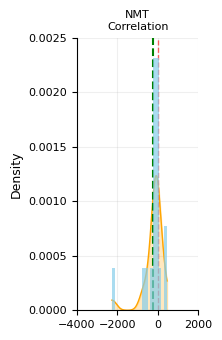

In [26]:

# Iterate over all possible datasets and features in the data for plotting

datasets = ratio_df_all["dataset"].unique()
features = ratio_df_all["feature"].unique()

plot_pairs = []
for dataset in datasets:
    for feature in features:
        subgrp = ratio_df_all[(ratio_df_all["dataset"] == dataset) & (ratio_df_all["feature"] == feature)]
        if len(subgrp) > 0:
            fancy_title = ratio_df_all[(ratio_df_all["dataset"] == dataset) & (ratio_df_all["feature"] == feature)]["title_for_plot"].unique()[0]
            plot_pairs.append((dataset, feature, subgrp, fancy_title))

nplots = len(plot_pairs)
ncols = 5
nrows = int(np.ceil(nplots / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.2, 3.5))
axes = axes.flatten()

for i, (dataset, feature, group, fancy_title) in enumerate(plot_pairs):
    ax = axes[i]
    statistic = (group["ratio"] - 1) * 100

    # Plot histogram
    counts, bins, patches = ax.hist(
        statistic, bins=20, color='skyblue', alpha=0.7, density=True, label='Histogram',
        zorder=3
    )

    # Plot KDE
    if len(statistic) > 1:
        xmin, xmax = bins[0], bins[-1]
        x = np.linspace(xmin, xmax, 500)
        kde = stats.gaussian_kde(statistic, bw_method=0.4)
        y = kde(x)
        ax.plot(x, y, color='orange', linewidth=1, label='Density (KDE)', zorder=2)
        ax.fill_between(x, y, color='orange', alpha=0.25, zorder=2)
    else:
        xmin, xmax = ax.get_xlim()

    # Add mean line
    mean_val = np.mean(statistic)
    ax.axvline(mean_val, color='green', linestyle='--', label=f'Mean = {mean_val:.2f}')
    # Reference line at Zero Improvement
    ax.axvline(0, color="red", linestyle="--", lw=1, alpha=0.6, label="No Improvement")

    ax.set_title(f"{dataset}\n{fancy_title}", fontsize=8)
    if i == 0 or i == 5:
        ax.set_ylabel("Density", fontsize=9)
    else:
        ax.set_ylabel("")
    if i >= ncols:
        ax.set_xlabel("Improvement (%)", fontsize=9)
    else:
        ax.set_xlabel("")

    ax.set_xlim(xmin, xmax)

    fix_ticks(ax, 
              y=True,
              x=False,
              every_other=False,
              fontsize=8)
    
    fix_ticks(ax, 
              y=False,
              x=True,
              every_other=False,
              xlim=[xmin,xmax],
              fontsize=8)

    plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(alpha=0.2)

# Turn off extra axes (if any)
for j in range(len(plot_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/improvement_plot.svg", bbox_inches='tight')
plt.show()

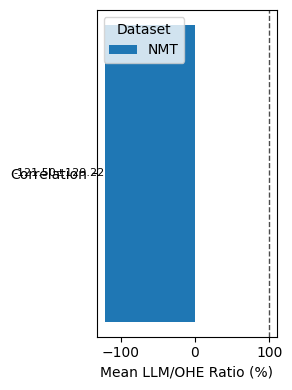

In [27]:

plot_source = ratio_df_all.copy()
plot_source["fancy_title"] = plot_source["title_for_plot"].fillna(plot_source["feature"])

# --- summarize at the exact level being plotted ---
summary_df = (
    plot_source
    .groupby(["dataset", "fancy_title"])["ratio"]
    .agg(["mean", "sem"])
    .reset_index()
    .rename(columns={"mean": "mean_ratio", "sem": "sem_ratio"})
)

# Multiply by 100 to convert to percent
summary_df["mean_ratio"] = summary_df["mean_ratio"] * 100
summary_df["sem_ratio"] = summary_df["sem_ratio"] * 100

# Orders
hue_order = sorted(summary_df["dataset"].dropna().unique())
y_order = list(summary_df["fancy_title"].drop_duplicates())

# Pivot so means and SEMs align exactly
mean_piv = (
    summary_df
    .pivot(index="fancy_title", columns="dataset", values="mean_ratio")
    .reindex(y_order)
)

sem_piv = (
    summary_df
    .pivot(index="fancy_title", columns="dataset", values="sem_ratio")
    .reindex(y_order)
)

# --- plot manually ---
fig, ax = plt.subplots(figsize=(3, 4))

n_hue = len(hue_order)
y = np.arange(len(y_order))
total_height = 0.8
bar_height = total_height / max(n_hue, 1)

palette = sns.color_palette("tab10", n_colors=n_hue)

bars = []
labels = []

for i, dataset in enumerate(hue_order):
    offset = (i - (n_hue - 1) / 2) * bar_height

    vals = mean_piv[dataset].to_numpy(dtype=float)
    errs = sem_piv[dataset].to_numpy(dtype=float)

    mask = ~np.isnan(vals)

    bar = ax.barh(
        y[mask] + offset,
        vals[mask],
        height=bar_height,
        #xerr=errs[mask],
        capsize=3,
        color=palette[i],
        label=dataset,
        edgecolor="none"
    )
    bars.append(bar)
    labels.append(dataset)

    # Add ± values as text on each bar
    for j, (yy, val, err) in enumerate(zip(y[mask] + offset, vals[mask], errs[mask])):
        if not np.isnan(val) and not np.isnan(err):
            text = f"{val:.2f}±{err:.2f}"
            # Place text at right end of the bar, a bit to the right if val > 0, else to the left
            xloc = val + 0.02 if val >= 0 else val - 0.02  # Adjust as needed
            ha = "left" if val >= 0 else "right"
            ax.text(xloc, yy, text, va='center', ha=ha, fontsize=8, color="black")

ax.set_yticks(y)
ax.set_yticklabels(y_order)
ax.invert_yaxis()
ax.set_xlabel("Mean LLM/OHE Ratio (%)")
ax.set_ylabel("")
ax.axvline(x=100, color="k", linestyle="--", linewidth=1, alpha=0.7)

# Add legend
ax.legend(title="Dataset", loc="best")

#ax.set_xlim(20, 130)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3397747/3541086354.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


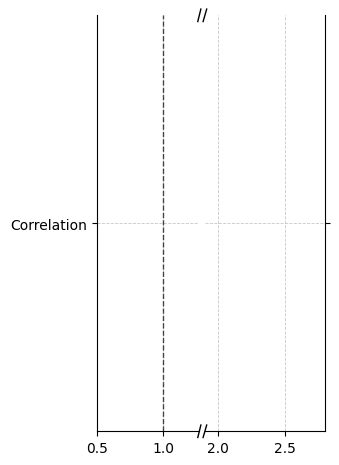

In [28]:

# --- attach title_for_plot at the row level first ---
plot_source = ratio_df_all.copy()
plot_source["fancy_title"] = plot_source["title_for_plot"].fillna(plot_source["feature"])

# --- summarize at the exact level being plotted ---
summary_df = (
    plot_source
    .groupby(["dataset", "fancy_title"])["ratio"]
    .agg(["mean", "sem"])
    .reset_index()
    .rename(columns={"mean": "mean_ratio", "sem": "sem_ratio"})
)

# Orders
hue_order = sorted(summary_df["dataset"].dropna().unique())
y_order = list(summary_df["fancy_title"].drop_duplicates())

# Pivot so means and SEMs align exactly
mean_piv = (
    summary_df
    .pivot(index="fancy_title", columns="dataset", values="mean_ratio")
    .reindex(y_order)
)

sem_piv = (
    summary_df
    .pivot(index="fancy_title", columns="dataset", values="sem_ratio")
    .reindex(y_order)
)

# --- broken x-axis setup ---
left_xlim = (0.5, 1.27)
right_xlim = (1.9, 2.8)

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(74.844/25.4, 137.214/25.4),
    gridspec_kw={
        "width_ratios": [left_xlim[1] - left_xlim[0], right_xlim[1] - right_xlim[0]],
        "wspace": 0.05
    }
)

n_hue = len(hue_order)
y = np.arange(len(y_order))
total_height = 0.8
bar_height = total_height / max(n_hue, 1)

palette = sns.color_palette("tab10", n_colors=n_hue)

for i, dataset in enumerate(hue_order):
    offset = (i - (n_hue - 1) / 2) * bar_height

    vals = mean_piv[dataset].to_numpy(dtype=float)
    errs = sem_piv[dataset].to_numpy(dtype=float)
    mask = ~np.isnan(vals)

    y_pos = y[mask] + offset
    vals_plot = vals[mask]
    errs_plot = errs[mask]

    # Plot same bars on both axes; clipping will make the break effect
    for ax in (ax1, ax2):
        ax.barh(
            y_pos,
            vals_plot,
            height=bar_height,
            #xerr=errs_plot,
            capsize=3,
            color=palette[i],
            label=dataset,
            edgecolor="none"
        )

# Limits
ax1.set_xlim(*left_xlim)
ax2.set_xlim(*right_xlim)

# Y axis
ax1.set_yticks(y)
ax1.set_yticklabels(y_order)
ax1.invert_yaxis()

# Hide duplicate y-axis on the right
ax2.tick_params(axis="y", left=False, labelleft=False)

# Labels
ax1.set_ylabel("")
ax1.set_xlabel("")
ax2.set_xlabel("")

# Vertical reference line at x=1
ax1.axvline(x=1, color="k", linestyle="--", linewidth=1, alpha=0.7)

# Clean up spines: remove top and right
for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Only keep left spine for ax1 and right for ax2
ax1.spines["left"].set_visible(True)
ax2.spines["left"].set_visible(False)
ax2.spines["right"].set_visible(True)
ax1.yaxis.tick_left()
ax2.yaxis.tick_right()

# Add gridlines
for ax in (ax1, ax2):
    ax.xaxis.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    ax.yaxis.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)

# Remove legend if wanted
if ax1.get_legend() is not None:
    ax1.get_legend().remove()
if ax2.get_legend() is not None:
    ax2.get_legend().remove()

# Draw diagonal break marks
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)        # bottom-right diagonal
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # top-right diagonal

kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False, linewidth=1)
ax2.plot((-d, +d), (-d, +d), **kwargs)              # bottom-left diagonal
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)        # top-left diagonal

plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/improvement_boxplot_plot.svg", bbox_inches='tight')
plt.show()

## Subsamples from `by_subsamples_all_new.ipynb`

This section uses the visualization logic from `by_subsamples_all_new.ipynb`, adapted to the current collected random scorer outputs (`random_full.csv` / `random_internal.csv`).

In [31]:
# Prepare subsample/random results using the schema from by_subsamples_all_new.ipynb.
# Change this to "full", "random_internal", or "all".
SUBSAMPLE_OUTPUT_DIR = Path("./refined_figures/figure_ohe_vs_llm")
SUBSAMPLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUBSAMPLE_VALIDATION_METHOD = "random_internal"

# None means infer all available metric columns. You can also set, e.g. ["correlation"].
SUBSAMPLE_STATISTICS = None


def _subsample_iteration_from_row(row):
    if "split_name" in row and pd.notna(row["split_name"]):
        text = str(row["split_name"])
        parts = text.split("_")
        for part in reversed(parts):
            try:
                return int(part)
            except ValueError:
                continue
    if "source_file" in row and pd.notna(row["source_file"]):
        text = Path(str(row["source_file"])).stem
        parts = text.split("_")
        for part in reversed(parts):
            try:
                return int(part)
            except ValueError:
                continue
    return 1


def _subsample_statistic_columns(df, requested=None):
    candidates = [
        ("correlation", "Correlation"),
        ("roc", "roc"),
        ("roc_auc", "roc"),
        ("precision", "precision"),
        ("f1", "f1"),
        ("accuracy", "accuracy"),
        ("recall", "recall"),
        ("top_100_pct", "top_100_pct"),
        ("precision_at_k", "precision_at_k"),
        ("precision_0_at_k", "precision_0_at_k"),
        ("precision_1_at_k", "precision_1_at_k"),
        ("mse", "mse"),
    ]
    if requested is not None:
        requested = set(requested)
        candidates = [(col, label) for col, label in candidates if col in requested or label in requested]
    out = []
    seen_labels = set()
    for col, label in candidates:
        if col in df.columns and df[col].notna().any() and label not in seen_labels:
            out.append((col, label))
            seen_labels.add(label)
    return out


def _best_plm_for_statistic(df, metric_col):
    plm = df[df["model_name"] != "ohe"].copy()
    if plm.empty:
        return None
    medians = plm.groupby("model_name")[metric_col].median().dropna()
    if medians.empty:
        return None
    return medians.idxmin() if metric_col == "mse" else medians.idxmax()


def make_subsamples_final_df(current, method=SUBSAMPLE_VALIDATION_METHOD, statistics=SUBSAMPLE_STATISTICS):
    random_df = select_random_validation_data(current, method)
    if random_df.empty:
        print("[subsamples] no random rows found")
        return pd.DataFrame()

    metric_cols = _subsample_statistic_columns(random_df, requested=statistics)
    print("[subsamples] statistics:", metric_cols)
    rows = []
    dataset_label = str(DATASET_NAME).upper()

    for metric_col, statistic_type in metric_cols:
        metric_df = random_df.dropna(subset=[metric_col]).copy()
        best_plm = _best_plm_for_statistic(metric_df, metric_col)
        print(f"[subsamples] {statistic_type}: best PLM={best_plm}")
        if best_plm is None:
            keep_df = metric_df[metric_df["model_name"] == "ohe"].copy()
        else:
            keep_df = metric_df[metric_df["model_name"].isin(["ohe", best_plm])].copy()

        for _, row in keep_df.iterrows():
            model_name = row["model_name"]
            rows.append({
                "N_samples": int(row["train_mutations"]),
                "iter": _subsample_iteration_from_row(row),
                "dataset": dataset_label,
                "value": float(row[metric_col]),
                "group": "OHE" if model_name == "ohe" else "PLM",
                "shuffle": False,
                "statistic_type": statistic_type,
                "model_name": model_name,
                "architecture_name": row.get("architecture_name", np.nan),
                "architecture_resolution": row.get("architecture_resolution", np.nan),
                "source_file": row.get("source_file", np.nan),
            })

    final = pd.DataFrame(rows)
    if final.empty:
        return final
    final = (
        final.groupby(["N_samples", "iter", "dataset", "group", "shuffle", "statistic_type"], as_index=False)
        .agg({
            "value": "median",
            "model_name": lambda values: ";".join(sorted({str(value) for value in values.dropna()})),
            "architecture_name": lambda values: ";".join(sorted({str(value) for value in values.dropna()})),
            "architecture_resolution": lambda values: ";".join(sorted({str(value) for value in values.dropna()})),
            "source_file": lambda values: ";".join(sorted({str(value) for value in values.dropna()})),
        })
        .sort_values(["dataset", "statistic_type", "group", "N_samples", "iter"])
        .reset_index(drop=True)
    )
    print("[subsamples] final_df_all", final.shape)
    return final


random_current = load_random_scorer_data()
for key, value in random_current.items():
    print(key, value.shape)

final_df_all = make_subsamples_final_df(random_current, SUBSAMPLE_VALIDATION_METHOD, SUBSAMPLE_STATISTICS)
display(final_df_all.head())
if not final_df_all.empty:
    print(final_df_all.groupby(["dataset", "statistic_type", "group"]).size())


random_full (150, 30)
random_internal (150, 30)
random_all (300, 30)
[select] random validation method=random_internal source=random_internal rows=150
[subsamples] statistics: [('correlation', 'Correlation'), ('mse', 'mse')]
[subsamples] Correlation: best PLM=esm_35m
[subsamples] mse: best PLM=esm_8m
[subsamples] final_df_all (200, 11)


,N_samples,iter,dataset,group,shuffle,statistic_type,value,model_name,architecture_name,architecture_resolution,source_file
0,25,1,NMT,OHE,False,Correlation,0.791249,ohe,mlp_16_128,random_internal,/home/labs/fleishman/itayta/new_fitness_repo/f...
1,25,2,NMT,OHE,False,Correlation,0.732099,ohe,mlp_128_64,random_internal,/home/labs/fleishman/itayta/new_fitness_repo/f...
2,25,3,NMT,OHE,False,Correlation,0.771652,ohe,mlp_16_128,random_internal,/home/labs/fleishman/itayta/new_fitness_repo/f...
3,25,4,NMT,OHE,False,Correlation,0.751914,ohe,mlp_64_64,random_internal,/home/labs/fleishman/itayta/new_fitness_repo/f...
4,25,5,NMT,OHE,False,Correlation,0.651908,ohe,mlp_128_32,random_internal,/home/labs/fleishman/itayta/new_fitness_repo/f...


dataset  statistic_type  group
NMT      Correlation     OHE      50
                         PLM      50
         mse             OHE      50
                         PLM      50
dtype: int64


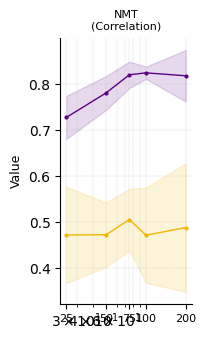

In [32]:

# --- Compute the plot_pairs in a specific order as above (see top cell context) ---
# Use the same order of datasets and statistic_types as in the subplot/histogram above
ordered_datasets = ["GFP", "LOV", "PARD3", "NMT", "GCN4", "PTE"]
ordered_statistic_types = ["precision", "precision_at_k", "precision_0_at_k", "precision_1_at_k", "roc", "f1", "accuracy", "recall", "top_100_pct", "Correlation"]

color_map = {
    "PLM": "#f0b800",
    "OHE": "#5d0187",
}

# Rather than plotting with plt.figure, do subplots like the main plot above for consistency:
plot_pairs = []
for dataset in ordered_datasets:
    for statistic_type in ordered_statistic_types:
        sub_df = final_df_all[(final_df_all["dataset"] == dataset) & 
                              (final_df_all["statistic_type"] == statistic_type)]
        if len(sub_df) > 0:
            plot_pairs.append((dataset, statistic_type, sub_df))

nplots = len(plot_pairs)
ncols = 5  # Same as @file_context_0 
nrows = int(np.ceil(nplots / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.2, 3.5))
axes = axes.flatten()

for i, (dataset, statistic_type, sub_df) in enumerate(plot_pairs):
    if sub_df.empty:
        continue

    ax = axes[i]

    # Value transform for gcn4/nmt
    if dataset.lower() == "gcn4" or dataset.lower() == "nmt":
        sub_df = sub_df.copy()
        sub_df["value"] = np.abs(sub_df["value"])

    # Plot each group (OHE/PLM), both shuffled and not shuffled
    for group in ['OHE', 'PLM']:
        base_color = color_map.get(group, None)
        for shuffle in [False]:
            _df = sub_df[(sub_df['group'] == group) & (sub_df['shuffle'] == shuffle)]
            if _df.empty:
                continue
            grouped = _df.groupby('N_samples')['value']
            avg = grouped.mean()
            std = grouped.std()
            sem = grouped.sem()
            n_samples = avg.index.values
            linestyle = '-' if not shuffle else '--'
            label = f'{group}{" (shuffled)" if shuffle else ""}'

            # Set color depending on group; for shuffled use lower alpha
            color = base_color
            if color is None:
                color = None  # Let matplotlib auto-assign if not provided
            alpha = 1.0 if not shuffle else 0.65

            # Plot with error bars (SEM)
            ax.errorbar(
                n_samples, avg.values,
                fmt=linestyle, capsize=3, label=label, marker='o',
                markersize=2,
                color=color, alpha=alpha, lw=1
            )

            if not shuffle:
                ax.fill_between(
                    n_samples, avg.values - std.values, avg.values + std.values,
                    alpha=0.15, color=color
                )

    IST = statistic_type.lower()
    ax.set_title(f"{dataset}\n({ylabel_dict[IST]})", fontsize=8)
    if i == 0 or i % ncols == 0:
        ax.set_ylabel("Value", fontsize=9)
    else:
        ax.set_ylabel("")
    ax.set_xscale('log')

    # Dynamically set x-ticks if few values
    all_ticks = sorted(sub_df['N_samples'].unique())
    if len(all_ticks) <= 8:
        ax.set_xticks(all_ticks)
        ax.set_xticklabels([str(x) for x in all_ticks], fontsize=8)
    else:
        ax.tick_params(axis='x', labelsize=8)

    ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Optionally fix ticks utility (if available)
    #fix_ticks(ax, y=True, x=False, every_other=False, fontsize=9)


# Turn off extra axes
for j in range(len(plot_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/ohe_plm_metrics_by_dataset_statistic_subplot.svg", bbox_inches='tight')
plt.show()


Number of ratio values more than 4 stds from the mean: 1
########################
1.6941840803760195
1.6436434331797236
0.37515831402763083
69.41840803760194
64.36434331797236
37.515831402763084
########################


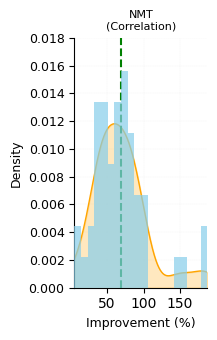

In [35]:

df_for_error_bars = []

# Prepare combinations for subplots
plot_pairs = []
for dataset in ["GFP", "LOV", "PARD3", "NMT", "GCN4", "PTE"]:
    for statistic_type in ["precision", "precision_at_k", "precision_0_at_k", "precision_1_at_k", "roc", "f1", "accuracy", "recall", "top_100_pct", "Correlation"]:
        sub_df = final_df_all[(final_df_all["dataset"] == dataset) &
                              (final_df_all["statistic_type"] == statistic_type) &
                              (final_df_all["shuffle"] == False)]

        if len(sub_df) > 0:
            plot_pairs.append((dataset, statistic_type, sub_df))
        else:
            continue

nplots = len(plot_pairs)
ncols = 5
nrows = int(np.ceil(nplots / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.2, 3.5))
axes = axes.flatten()

for i, (dataset, statistic_type, sub_df) in enumerate(plot_pairs):
    if sub_df.empty:
        continue

    ohe_values_df = sub_df[sub_df["group"] == "OHE"]
    plm_values_df = sub_df[sub_df["group"] == "PLM"]

    ohe_values_df_sorted = ohe_values_df.sort_values(["N_samples", "iter"])
    plm_values_df_sorted = plm_values_df.sort_values(["N_samples", "iter"])

    # Make sure we compare same samples/iterations
    assert sum(ohe_values_df_sorted["iter"].to_numpy() == plm_values_df_sorted["iter"].to_numpy()) == len(ohe_values_df_sorted)
    assert sum(ohe_values_df_sorted["N_samples"].to_numpy() == plm_values_df_sorted["N_samples"].to_numpy()) == len(ohe_values_df_sorted)

    plm_values = plm_values_df_sorted["value"].to_numpy()
    ohe_values = ohe_values_df_sorted["value"].to_numpy()

    ohe_values = ohe_values[plm_values != 0]
    plm_values = plm_values[plm_values != 0]

    if dataset == "GCN4" or dataset == "NMT":
        ratio = np.abs(ohe_values) / np.abs(plm_values)
    else:
        ratio = ohe_values / plm_values

    # Remove values more than 4 std deviations from the mean in ratio and print their count
    ratio_mean = np.mean(ratio)
    ratio_std = np.std(ratio)
    outlier_mask = np.abs(ratio - ratio_mean) > (3 * ratio_std)
    num_outliers = np.sum(outlier_mask)
    print(f"Number of ratio values more than 4 stds from the mean: {num_outliers}")
    ratio = ratio[~outlier_mask]
    ohe_values = ohe_values[~outlier_mask]
    plm_values = plm_values[~outlier_mask]
    statistic = (ratio - 1) * 100

    # Optional: Additional statistics printout
    print("########################")
    print(np.mean(ratio))
    print(np.median(ratio))
    print(np.std(ratio))
    print(np.mean(statistic))
    print(np.median(statistic))
    print(np.std(statistic))
    print("########################")

    df_for_error_bars.append({
        "dataset": dataset,
        "statistic_type": statistic_type,
        "statistic": statistic,
        "ratio": ratio,
        "mean_ratio": np.mean(ratio),
        "std_ratio": np.std(ratio),
        "sem_ratio": np.std(ratio) / np.sqrt(len(ratio)),
        "mean": np.mean(statistic),
        "std": np.std(statistic),
        "sem": np.std(statistic) / np.sqrt(len(statistic)),
        "ohe_values": ohe_values,
        "plm_values": plm_values,
    })

    ax = axes[i]
    # Plot histogram
    counts, bins, patches = ax.hist(
        statistic, bins=20, color='skyblue', alpha=0.7, density=True, label='Histogram',
        zorder=3
    )

    # Plot KDE
    if len(statistic) > 1:
        xmin, xmax = bins[0], bins[-1]
        x = np.linspace(xmin, xmax, 500)
        kde = stats.gaussian_kde(statistic, bw_method=0.4)
        y = kde(x)
        ax.plot(x, y, color='orange', linewidth=1, label='Density (KDE)', zorder=2)
        ax.fill_between(x, y, color='orange', alpha=0.25, zorder=2)
    else:
        xmin, xmax = ax.get_xlim()

    # Add mean line
    mean_val = np.mean(statistic)
    ax.axvline(mean_val, color='green', linestyle='--', label=f'Mean = {mean_val:.2f}')
    ax.axvline(0, color="red", linestyle="--", lw=1, alpha=0.6, label="No Improvement")
    IST = statistic_type.lower()
    ax.set_title(f"{dataset}\n({ylabel_dict[IST]})", fontsize=8)

    if i == 0 or i % ncols == 0:
        ax.set_ylabel("Density", fontsize=9)
    else:
        ax.set_ylabel("")
    if i >= ncols * (nrows - 1):
        ax.set_xlabel("Improvement (%)", fontsize=9)
    else:
        ax.set_xlabel("")
    ax.set_xlim(xmin, xmax)

    # Optionally fix ticks here if you have a fix_ticks utility function
    fix_ticks(ax, y=True, x=False, every_other=False, fontsize=9)
    #fix_ticks(ax, y=False, x=True, every_other=False, xlim=[xmin, xmax], fontsize=9)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(alpha=0.2, linestyle='--', linewidth=0.25)

# Turn off extra axes (if any)
for j in range(len(plot_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/improvement_by_statistic_type_subplot.svg", bbox_inches='tight')
plt.show()

std_error_bars_df = pd.DataFrame(df_for_error_bars)



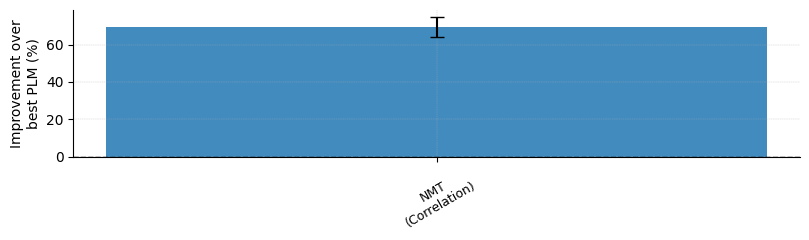

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Assume std_error_bars_df has columns: dataset, statistic_type, mean, sem, statistic

fig, ax = plt.subplots(figsize=(8.2, 2.5))

# Build x locations and labels (one for each row)
x_labels = [
    f"{row['dataset']}\n({ylabel_dict[row['statistic_type'].lower()]})"
    for _, row in std_error_bars_df.iterrows()
]
x = np.arange(len(std_error_bars_df))

# Plot barplot of means with error bars (sem)
bars = ax.bar(
    x, std_error_bars_df["mean"],
    yerr=std_error_bars_df["sem"],
    color="C0", alpha=0.85, capsize=5, width=0.25,
    ecolor="black",
    label="Mean ± SEM"
)

# # # Optionally overlay all observations as scatter (dotplot) for each group
# for i, (_, row) in enumerate(std_error_bars_df.iterrows()):
#     if isinstance(row["statistic"], (list, np.ndarray)):
#         n = len(row["statistic"])
#         # jitter x
#         jittered_x = np.random.normal(loc=x[i], scale=0.09, size=n)
#         ax.scatter(
#             jittered_x, row["statistic"],
#             color="black", s=13, alpha=0.5, lw=0, zorder=2
#         )

# Style the plot as reference
tick_locations = x
plt.grid(True, which='major', linestyle='--', linewidth=0.3, alpha=0.7)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(tick_locations, x_labels, rotation=30, ha='center', fontsize=9)
plt.ylabel("Improvement over\nbest PLM (%)", fontsize=10)
plt.xlabel("")
#plt.yscale("log")

plt.axhline(0, color='k', linestyle='dashed', lw=1)
plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/summarized_improvement_by_statistic_type.svg", bbox_inches='tight')
plt.show()
